## Fall Prevention in Elderly people utilizing Deep Learning & Wearable Sensors.

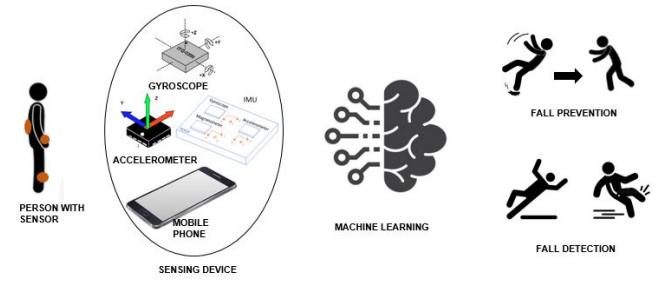

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# general 
import pandas as pd 
import numpy as np

# plotting 
import plotly.express as px
import matplotlib.pyplot as plt

# Dataset description
**36 total Activities**
*   21 Activities of Daily Livings 
*   15 Fall Activities

**Total Subjects 32 (each activity is performed 5 times)**
*   2729 ADL motions
*   2346 fall motions

In [3]:
# Dictionary for all "Activities of Dailiy Livings" & "Falls" (Total 36 classes)
task_dict={
    "T01":"Stand for 30 seconds (ADL)",
    "T02":"Stand, slowly bend the back with or without bending at knees, tie shoe lace, and get up (ADL)",
    "T03":"Pick up an object from the floor (ADL)",
    "T04":"Gently jump (try to reach an object) (ADL)",
    "T05":"Stand, sit to the ground, wait a moment, and get up with normal speed (ADL)",
    "T06":"Walk normally with turn (4m) (ADL)",
    "T07":"Walk quickly with turn (4m) (ADL)",
    "T08":"Jog normally with turn (4m) (ADL)",
    "T09":"Jog quickly with turn (4m) (ADL)",
    "T10":"Stumble while walking (ADL)",
    "T11":"Sit on a chair for 30 seconds (ADL)",
    "T12":"Sit on the sofa (back is inclined to the support) for 30 seconds (ADL)",
    "T13":"Sit down to a chair normally, and get up from a chair normally (ADL)",
    "T14":"Sit down to a chair quickly, and get up from a chair quickly (ADL)",
    "T15":"Sit a moment, trying to get up, and collapse into a chair (ADL)",
    "T16":"Stand, sit on the sofa (back is inclined to the support), and get up normally (ADL)",
    "T17":"Lie on the bed for 30 seconds (ADL)",
    "T18":"Sit a moment, lie down to the bed normally, and get up normally (ADL)",
    "T19":"Sit a moment, lie down to the bed quickly, and get up quickly (ADL)",
    "T20":"Forward fall when trying to sit down (FALL)",
    "T21":"Backward fall when trying to sit down (FALL)",
    "T22":"lateral fall when trying to sit down (FALL)",
    "T23" :"Forward fall when trying to get up (FALL)",
    "T24":"lateral fall when trying to get up (FALL)",
    "T25":"Forward fall while sitting, caused by fainting (FALL)",
    "T26":"lateral fall while sitting, caused by fainting (FALL)",
    "T27":"Backward fall while sitting, caused by fainting (FALL)",
    "T28":"Vertical(forward) fall while walking caused by fainting (FALL)",
    "T29":"Fall while walking, use of hands to dampen fall, caused by fainting (FALL)",
    "T30":"Forward fall while walking caused by a trip (FALL)",
    "T31":"Forward fall while jogging caused by a trip (FALL)",
    "T32":"Forward fall while walking caused by a slip (FALL)",
    "T33":"Lateral fall while walking caused by a slip (FALL)",
    "T34":"Backward fall while walking caused by a slip (FALL)",
    "T35":"Walk upstairs and downstairs normally (5 steps) (ADL)",
    "T36":"Walk upstairs and downstairs quickly (5 steps) (ADL)"
 }

In [4]:
df = pd.read_csv ('/content/drive/MyDrive/Thesis/K-Fall/merged_data/merged_data.csv')
df

,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,EulerX,EulerY,EulerZ,Acc_Mag,Gyr_Mag,Euler_Mag,Class_Label,Ex_Label,Task ID,Trial ID,Subject ID
0,0.01,1,-0.053,-1.004,0.000,-0.057296,0.401071,0.343775,87.788625,-2.859060,-20.202499,-8.794602,0.531339,90.128563,ADL,0,T01,R01,S06
1,0.02,2,-0.054,-1.007,0.000,-0.057296,0.229183,0.229183,87.788625,-2.864790,-20.196769,-8.791553,0.329139,90.127461,ADL,0,T01,R01,S06
2,0.03,3,-0.056,-1.009,-0.004,-0.458366,0.286479,0.171887,87.782895,-2.864790,-20.196769,-8.789439,0.567199,90.121880,ADL,0,T01,R01,S06
3,0.04,4,-0.053,-1.011,-0.009,-0.916733,0.458366,0.229183,87.771436,-2.870520,-20.191040,-8.787572,1.050249,90.109616,ADL,0,T01,R01,S06
4,0.05,5,-0.052,-1.012,-0.011,-1.088620,0.343775,0.401071,87.817273,-2.841872,-20.191040,-8.786605,1.210014,90.153357,ADL,0,T01,R01,S06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995095,8.16,816,-0.035,-1.004,0.138,-0.229183,-1.661578,2.578311,98.033114,-3.420559,-29.742250,-8.785956,3.075883,102.502649,ADL,0,T36,R05,S38
3995096,8.17,817,-0.030,-1.000,0.135,-0.630254,-1.375099,2.463719,98.027384,-3.443478,-29.759439,-8.790483,2.891026,102.502926,ADL,0,T36,R05,S38
3995097,8.18,818,-0.024,-0.997,0.131,-1.203212,-1.546987,2.349128,97.947170,-3.374723,-29.776627,-8.794144,3.059295,102.428924,ADL,0,T36,R05,S38
3995098,8.19,819,-0.019,-0.997,0.126,-1.776170,-1.776170,2.349128,97.929981,-3.391911,-29.799546,-8.794890,3.439180,102.419721,ADL,0,T36,R05,S38


# Daily Activites & Falls 
(Visualization)

In [5]:
df_lbl = pd.read_excel('/content/drive/MyDrive/Thesis/K-Fall/label_data/SA06_label.xlsx')
df = pd.read_csv ('/content/drive/MyDrive/Thesis/K-Fall/merged_data/after_impact_label.csv')

In [6]:
def plot(df,trial):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 5))
  fig.suptitle(task_dict[trial])

  # Acceleration
  ax1.plot(df['TimeStamp(s)'],  df['AccX'], label = "AccX")
  ax1.plot(df['TimeStamp(s)'],  df['AccY'], label = "AccY")
  ax1.plot(df['TimeStamp(s)'],  df['AccZ'], label = "AccZ")
  ax1.set(xlabel='TimeStamp(s)', ylabel='Accelaration')
  ax1.legend(loc="upper right")

  # Gyroscope
  plt.plot(df['TimeStamp(s)'],  df['GyrX'], label = "GyrX")
  plt.plot(df['TimeStamp(s)'],  df['GyrY'], label = "GyrY")
  plt.plot(df['TimeStamp(s)'],  df['GyrZ'], label = "GyrZ")
  plt.ylabel("Angular Velocity ")
  plt.xlabel("TimeStamp(s)")
  plt.legend()
  plt.show()

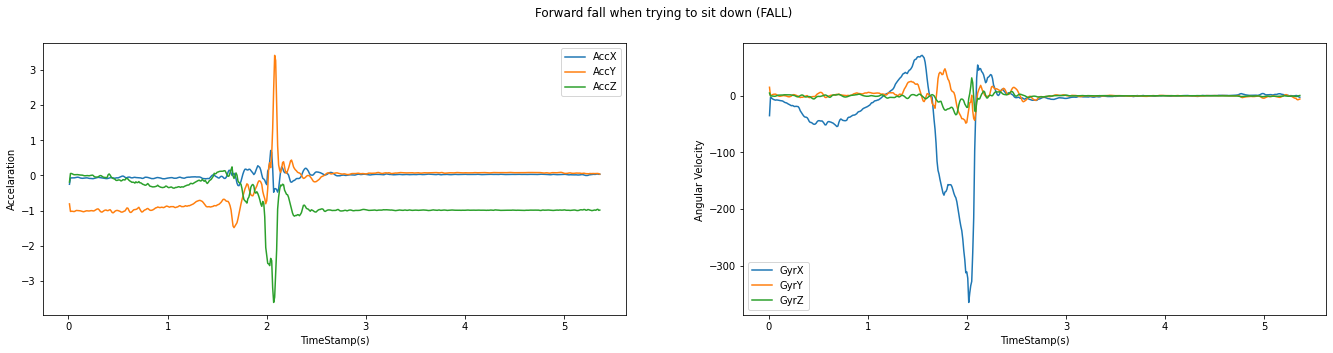

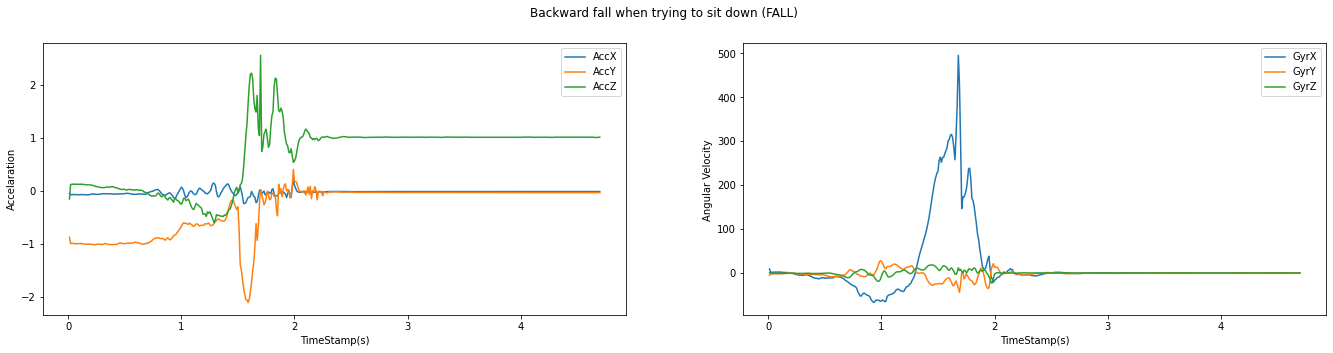

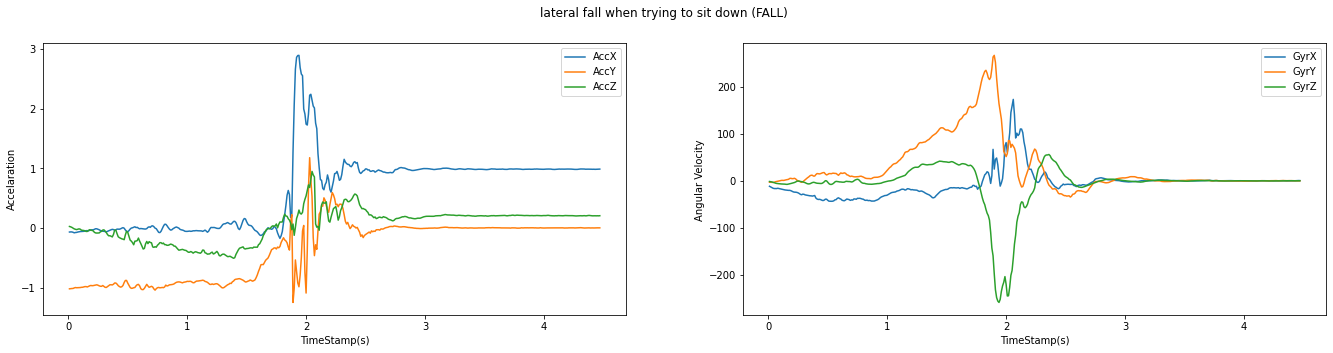

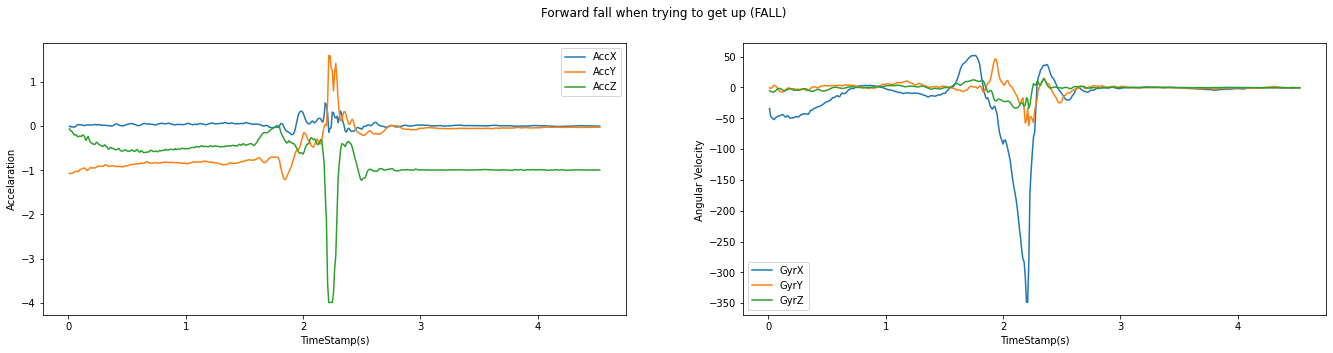

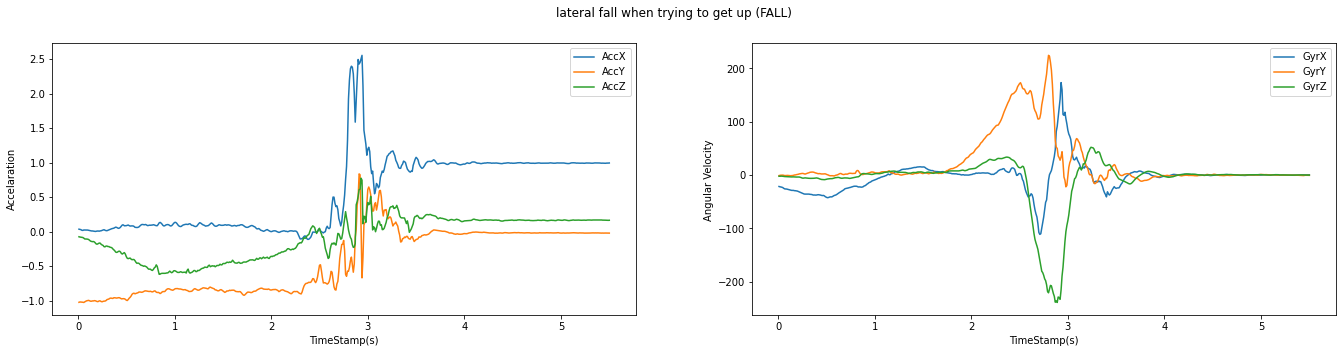

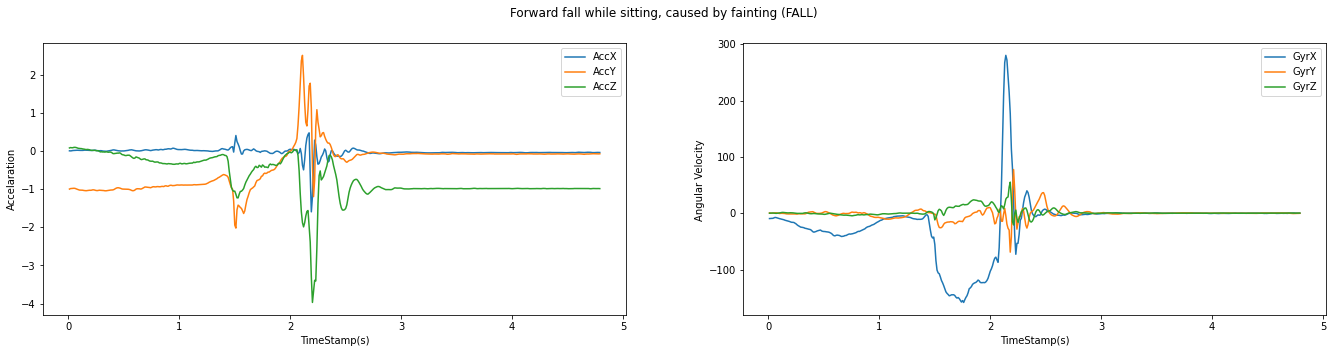

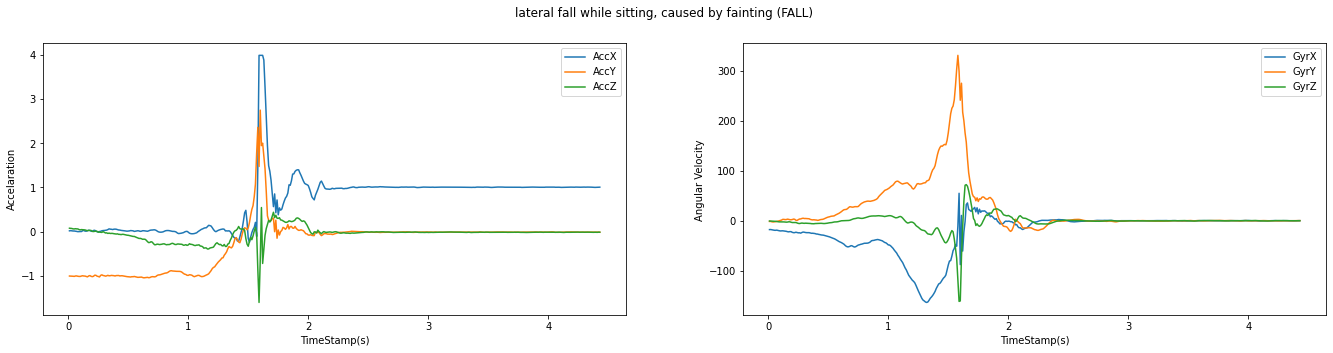

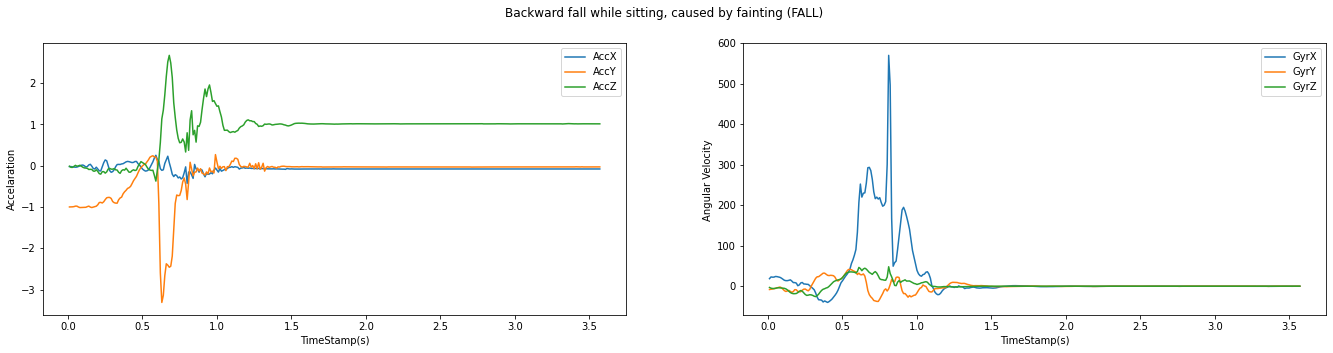

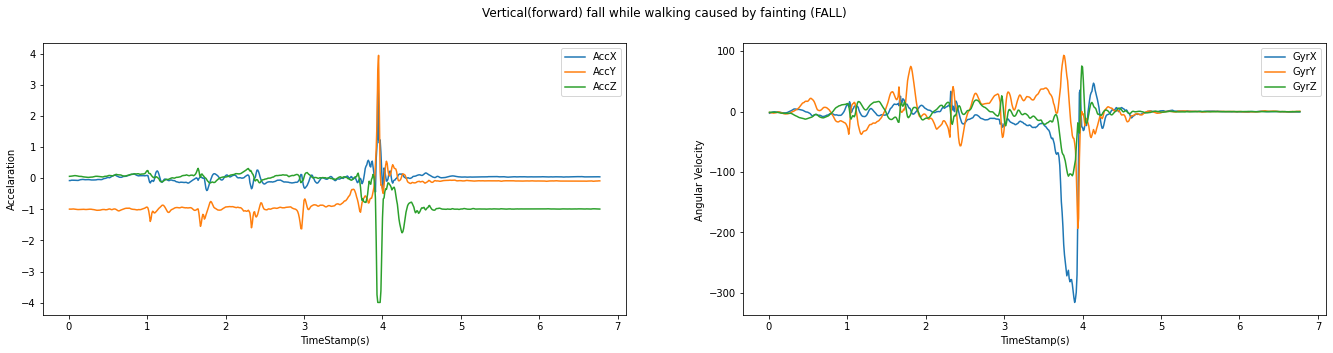

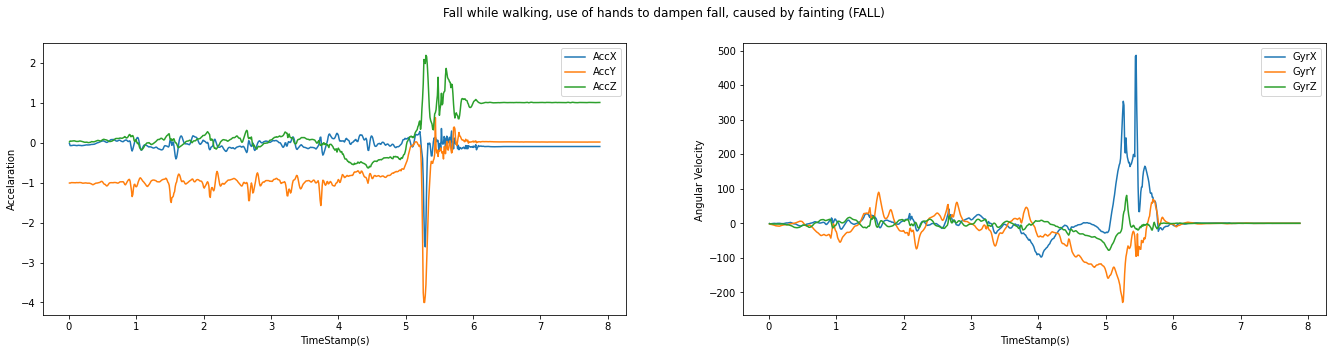

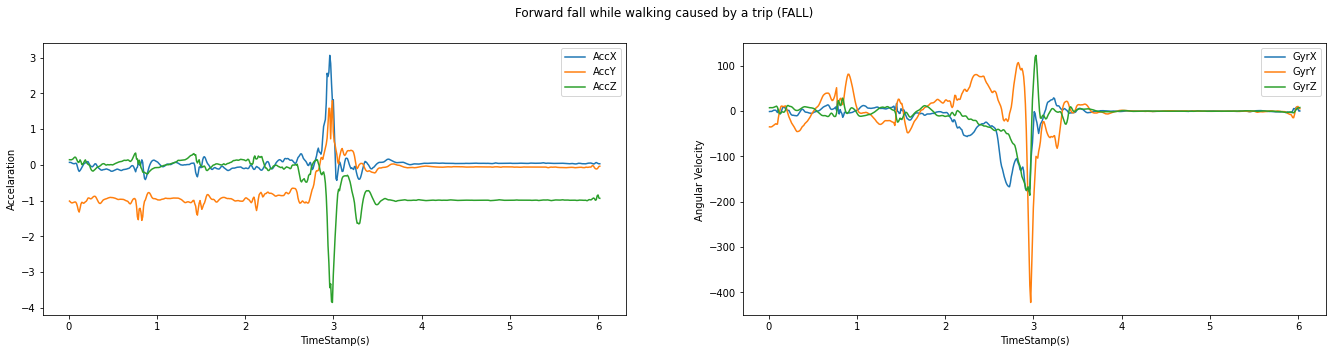

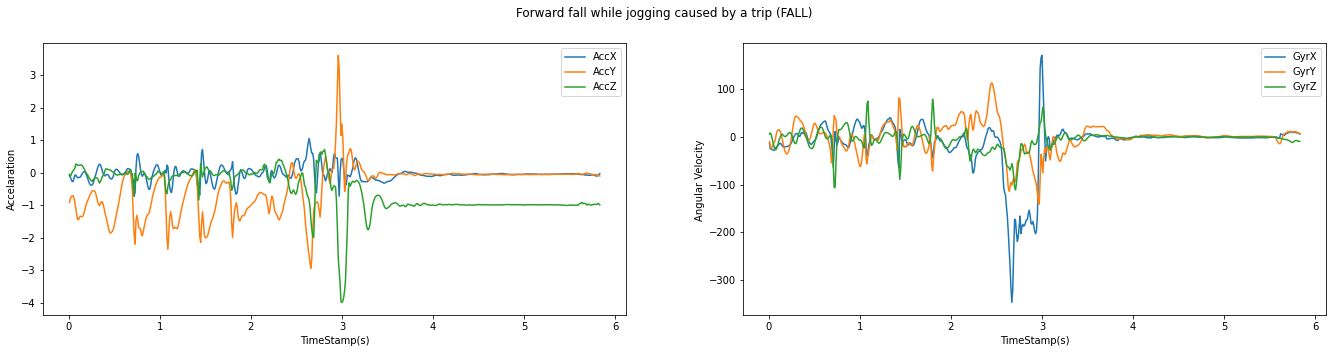

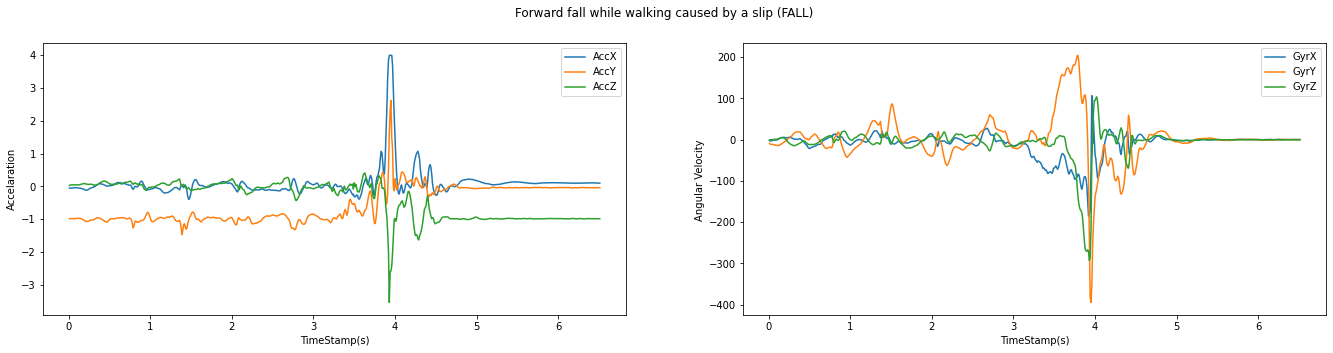

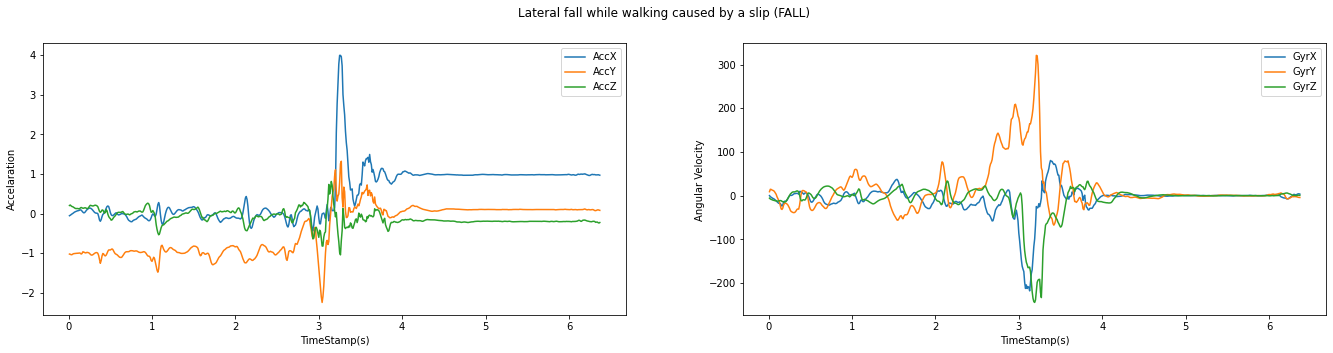

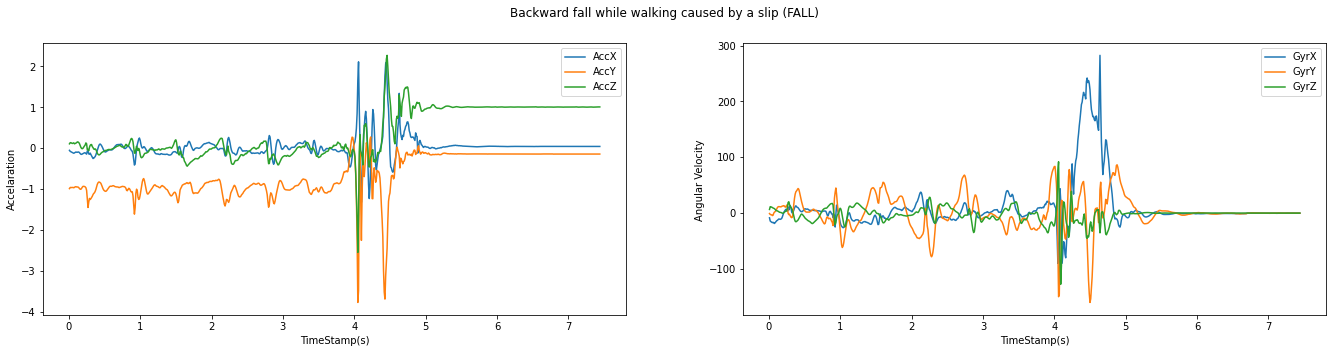

In [7]:
by_subject = df.groupby('Subject ID')
by_task = by_subject.get_group("S06").groupby("Task ID")
for trial, frame in by_task:
  by_trial = frame.groupby("Trial ID")
  try:
     by_trial=by_trial.get_group("R01")
  except:
     by_trial=by_trial.get_group("R02")
  plot(by_trial,trial)
  print('\n')


# Pre_Impact fall aka Fall Prevention


In [8]:
import warnings
warnings.filterwarnings("ignore", 'This pattern has match groups')

In [9]:
def plot(df,title):
      plt.figure(figsize=(17, 5))
      plt.title(title)
      print('\n')
      onset_frame =df.loc[df['Ex_Label'] == 2, 'TimeStamp(s)'].iloc[0]
      impact_frame =df.loc[df['Ex_Label'] == 3, 'TimeStamp(s)'].iloc[0]
      after_impact_frame=df.loc[df['Ex_Label'] == 4, 'TimeStamp(s)'].iloc[0]
      plt.vlines(x=[onset_frame,impact_frame,after_impact_frame], ymin=[-4, -4, -4], ymax=[5, 5, 5], colors='purple', label='Lead Time')
      plt.plot(df['TimeStamp(s)'],  df['AccX'], label = "AccX")
      plt.plot(df['TimeStamp(s)'],  df['AccY'], label = "AccY")
      plt.plot(df['TimeStamp(s)'],  df['AccZ'], label = "AccZ")
      plt.ylabel("Acceleration")
      plt.xlabel("TimeStamp(s)")
      plt.legend()
      plt.show()

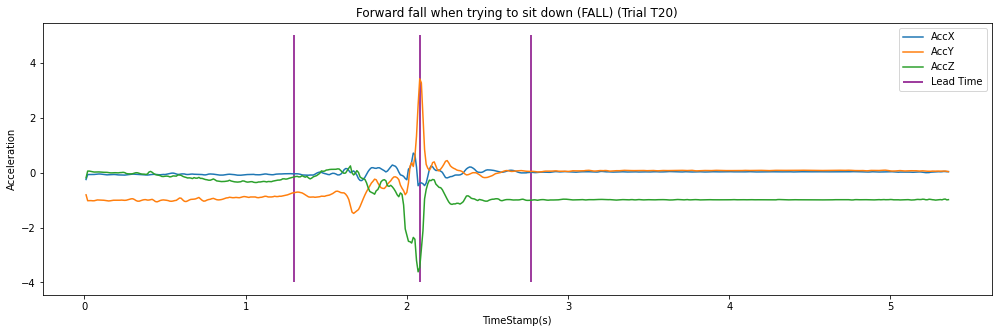

1




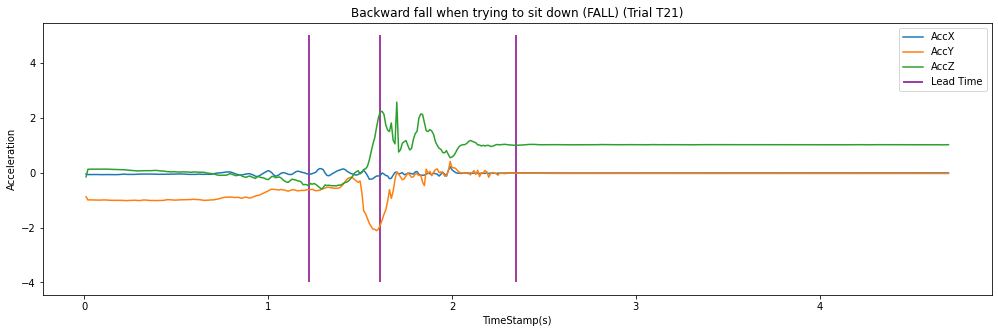

2




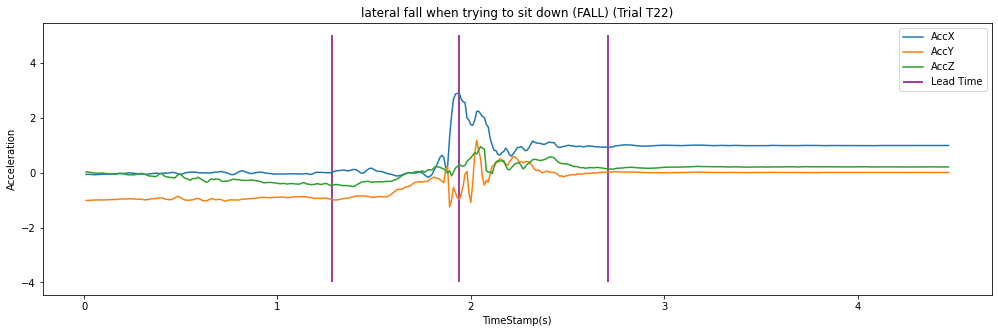

3




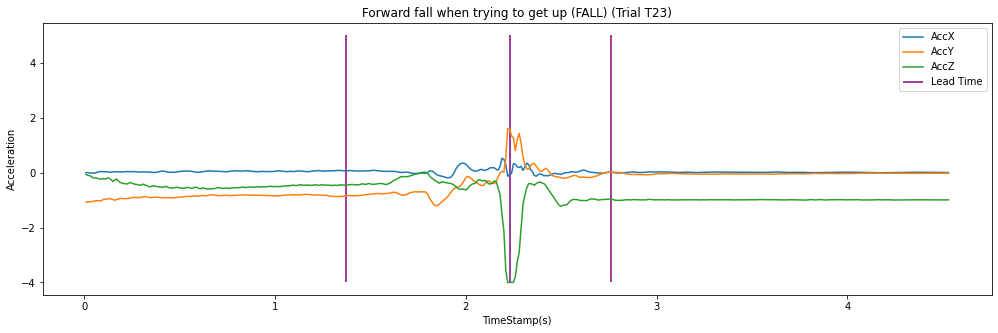

4




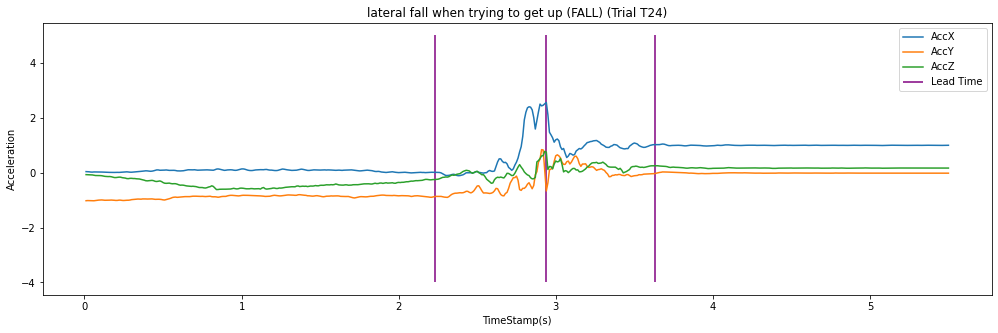

5




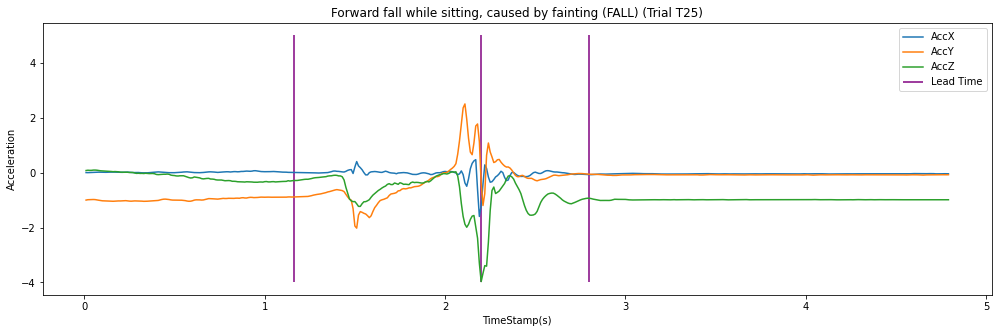

6




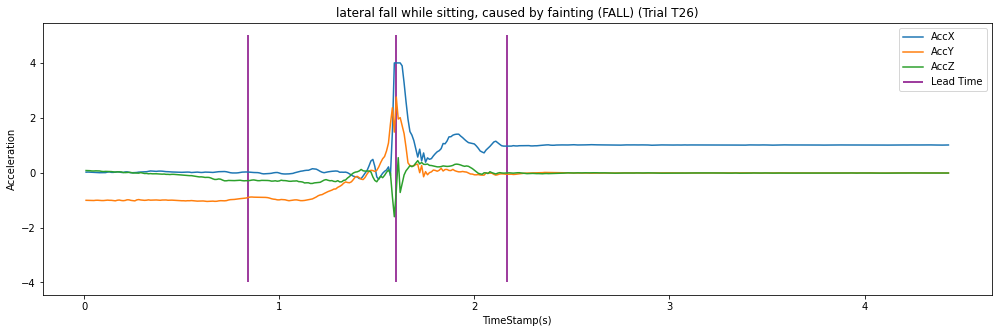

7




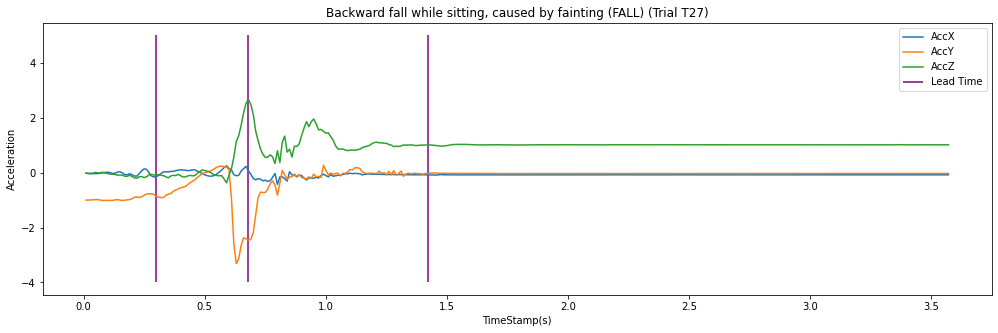

8




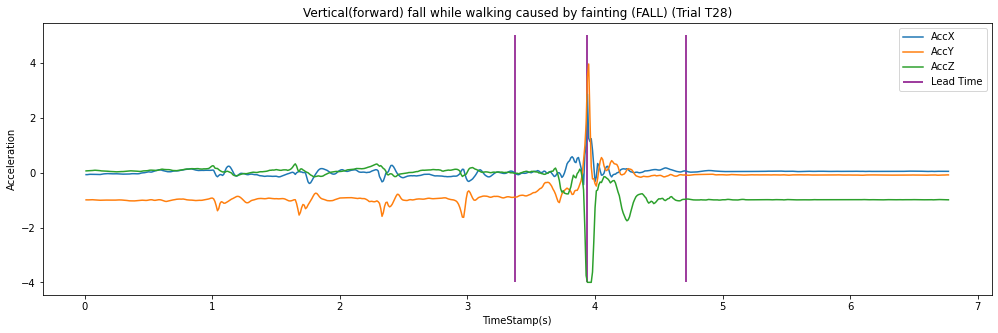

9




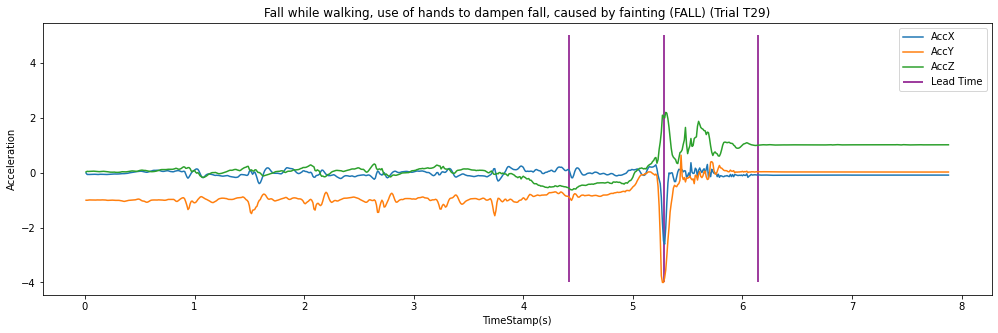

10




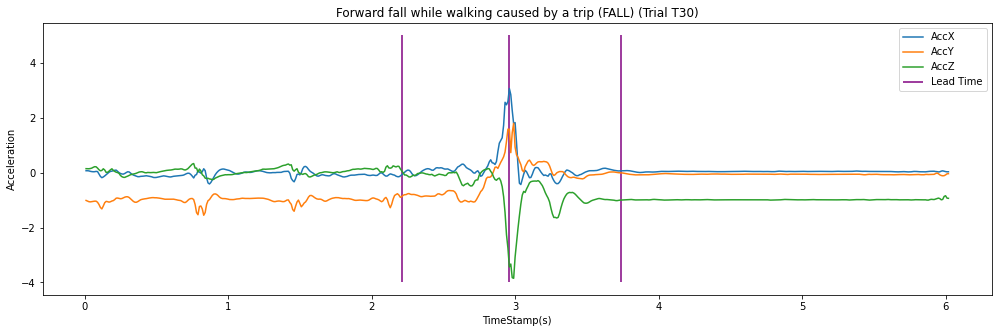

11




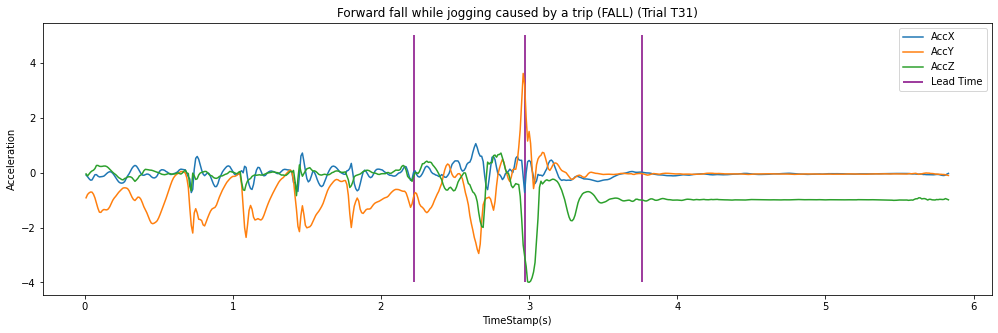

12




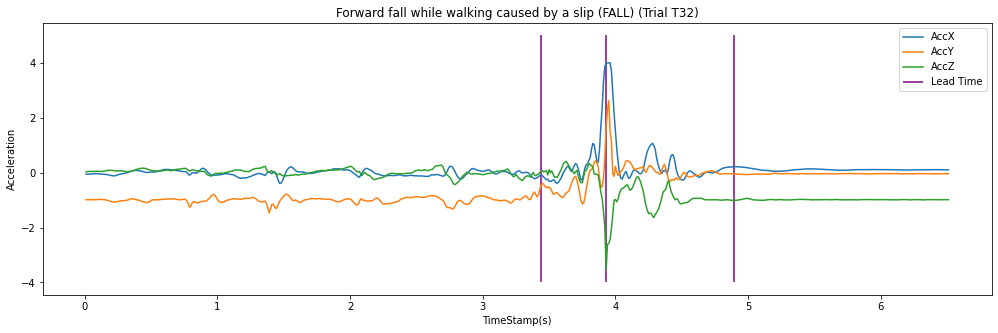

13




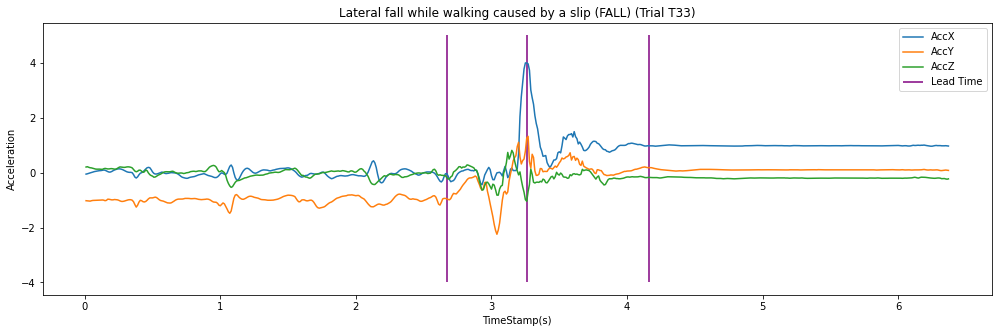

14




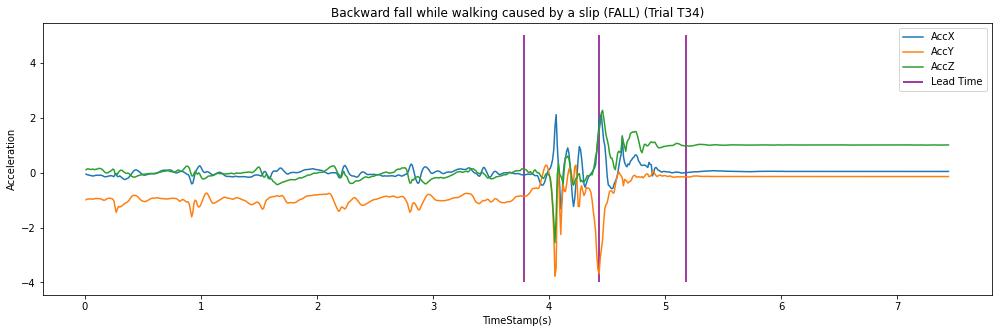

15


In [14]:
count =0
by_subject = df.groupby('Subject ID')
by_task = by_subject.get_group("S06").groupby("Task ID")
for name, data in by_task:
    task = task_dict[name]
    by_trial = data.groupby("Trial ID")
    try:
     by_trial=by_trial.get_group("R01")
    except:
     by_trial=by_trial.get_group("R02")
    data = by_trial[["TimeStamp(s)", "AccX", "AccY", "AccZ","Ex_Label"]]
    title = task+" (Trial "+name+")"
    plot(data,title)
    count = count+1
    print(count)


  

# Model Architecture (Inception-ResNet+Bi-GRU)

**Inception Block**

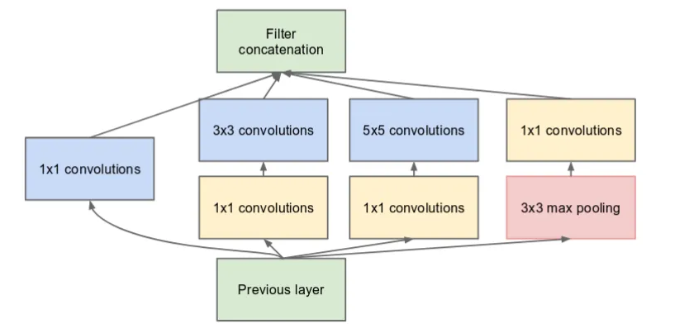

**Inception-Resnet**

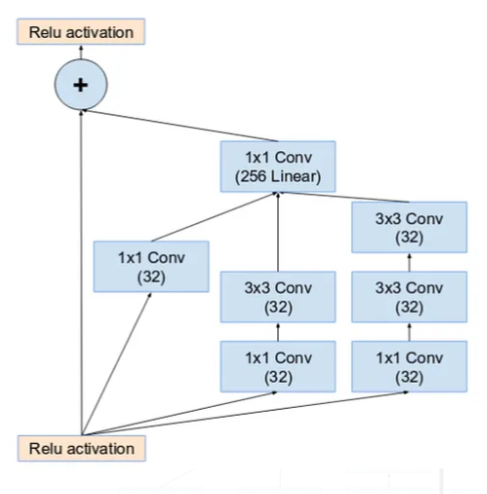

# Complete Model

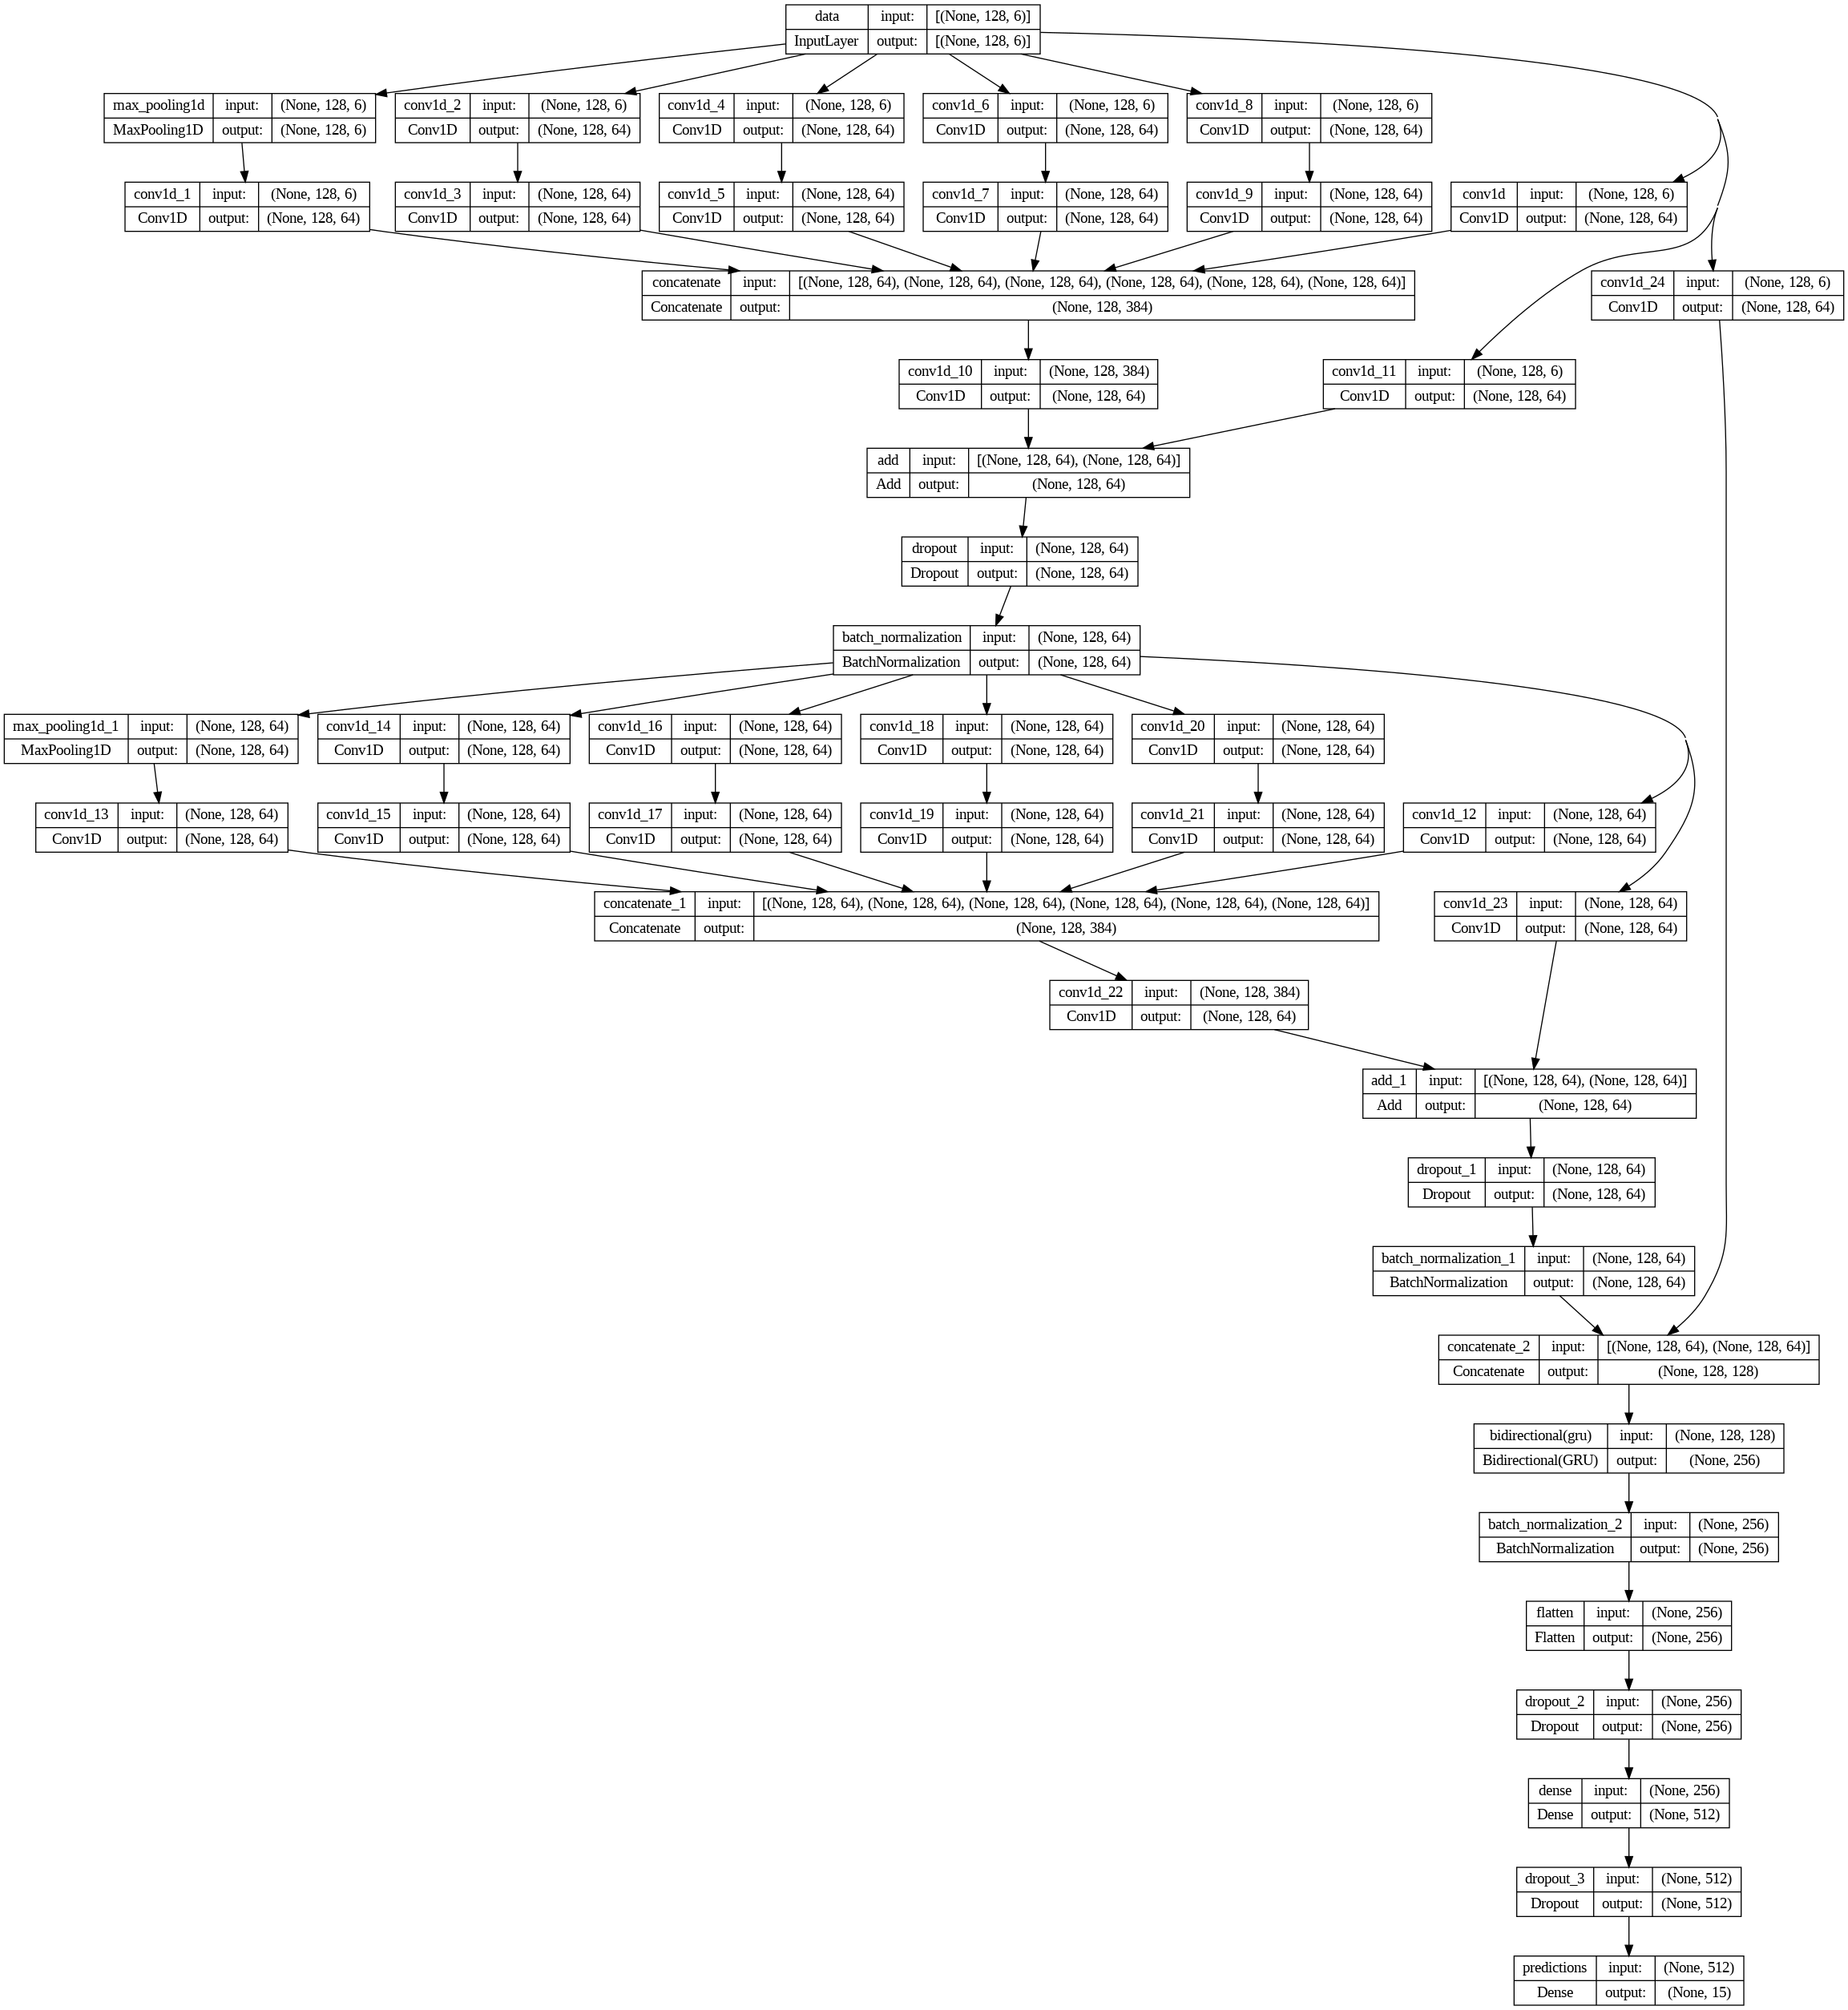